# Bachelier Model

**What this is:** Bachelier (1900) models the asset price as arithmetic Brownian
motion, which means it is price changes rather than returns that are normally
distributed.

**Why it matters:** Given that the dynamics are arithmetic, the process allows negative
prices, which is the main reason geometric Brownian motion displaced it for equities. It
returned to practical use in April 2020, when WTI crude futures settled below zero and
lognormal models could not price the market at all. It is also still the standard choice
for interest rate and spread options, since the underlying in both cases can legitimately
go negative.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
from __future__ import annotations

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

Array = npt.NDArray[np.float64]
RNG = int | np.random.Generator | None

plt.style.use('seaborn-v0_8')

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | initial asset price |
| $\sigma$ | `sigma` | volatility, in price units per $\sqrt{\text{year}}$ |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $\varepsilon_{i,j}$ | `epsilon` | independent standard normal shocks, $\varepsilon_{i,j} \sim \mathcal{N}(0,1)$ |

Note that $\sigma$ here is an absolute volatility quoted in price units, not the
proportional volatility used by geometric Brownian motion.

In [2]:
SEED = 20260913

S0 = 100
sigma = 2
T = 1
n = 252
dt = T/n
num_paths = 100

## Model

**Continuous time:**

$$dS_t = \sigma \, dW_t \quad \Longrightarrow \quad S_t = S_0 + \sigma W_t$$

where $W_t$ is a standard Brownian motion, $W_t \sim \mathcal{N}(0, t)$.

**Discrete time:** since the drift is zero and $\sigma$ is constant, the increments are
exactly Gaussian and no discretisation error is introduced. The scheme below is exact
rather than an Euler approximation.

$$S_{i,j} = S_0 + \sigma \sqrt{\Delta t} \sum_{m=1}^{i} \varepsilon_{m,j}$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n]$ and
$j \in [1, \texttt{num\_paths}]$.

**In code:** the running sum $\sum_{m=1}^{i} \varepsilon_{m,j}$ is
`np.cumsum(epsilon, axis=0)`, with $\varepsilon_{0,j} = 0$ inserted so that every path
starts at $S_0$. Arrays are stored as `(n + 1, num_paths)` throughout the repository, so
the array indexing matches the $(i, j)$ ordering used above.

In [3]:
def simulate_bachelier(S0: float, sigma: float, n: int, dt: float,
                       num_paths: int, rng: RNG = None) -> Array:
  """Arithmetic Brownian motion paths, shape (n+1, num_paths).

  Sampled exactly rather than by Euler: with zero drift and constant sigma the
  increments are Gaussian, so no discretisation error is introduced.

  Returns shape (n+1, num_paths), time along the first axis.
  """
  rng = np.random.default_rng(rng)
  epsilon = np.insert(rng.normal(0,1,(n,num_paths)),0,0,axis=0)
  return S0 + sigma * np.sqrt(dt) * np.cumsum(epsilon,axis=0)

paths = simulate_bachelier(S0, sigma, n, dt, num_paths, rng=SEED)

## Results

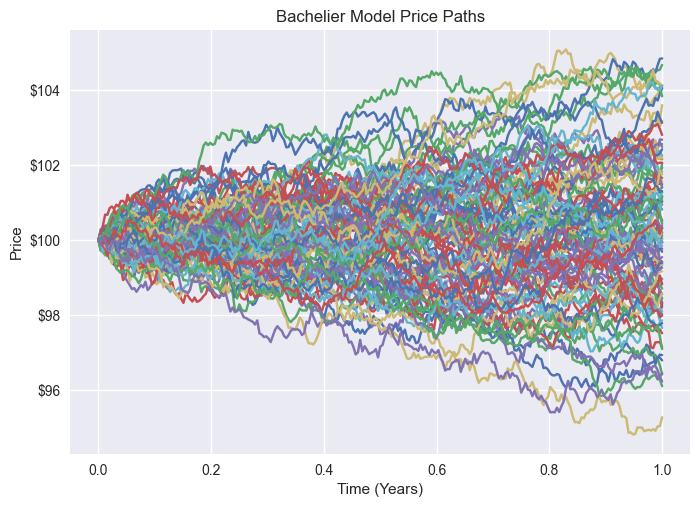

In [4]:
time_steps = np.linspace(0,T,n+1)

plt.plot(time_steps,paths)

plt.grid(True)
plt.xlabel("Time (Years)")
plt.ylabel("Price")
plt.title("Bachelier Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.show()